## Sales Forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
try:
    df = pd.read_csv('stores_sales_forecasting.csv')
except Exception as e:
    print(f"Error loading file: {e}")
    print("Using dummy data for demonstration...")
    data = {
        'Date': pd.date_range(start='2010-02-05', periods=100, freq='W-FRI'),
        'Weekly_Sales': np.random.randint(low=500000, high=2000000, size=100) * 1.0,
        'IsHoliday': np.random.choice([0, 1], size=100, p=[0.9, 0.1])
    }
    df = pd.DataFrame(data)

Error loading file: 'utf-8' codec can't decode byte 0xd2 in position 17654: invalid continuation byte
Using dummy data for demonstration...


In [3]:
DATE_COL = 'Date'
SALES_COL = 'Weekly_Sales'
HOLIDAY_COL = 'IsHoliday'


In [4]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

In [5]:
df.dropna(subset=[SALES_COL], inplace=True)


In [6]:
# Time-based features
df['Year'] = df[DATE_COL].dt.year
df['Month'] = df[DATE_COL].dt.month
df['Week'] = df[DATE_COL].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df[DATE_COL].dt.dayofweek # 0=Monday, 6=Sunday

In [7]:
df['Sales_Lag_1'] = df[SALES_COL].shift(1)
df['Sales_Lag_4'] = df[SALES_COL].shift(4)

In [8]:
df['Sales_Rolling_Mean_4'] = df[SALES_COL].shift(1).rolling(window=4).mean()

In [9]:
df.dropna(inplace=True)

In [10]:
features = [
    'Year', 'Month', 'Week', 'DayOfWeek', HOLIDAY_COL,
    'Sales_Lag_1', 'Sales_Lag_4', 'Sales_Rolling_Mean_4'
    ]
X = df[features]
y = df[SALES_COL]

In [11]:
#Test Model
test_size_ratio = 0.2 # Aakhri 20% data testing ke liye
split_index = int(len(df) * (1 - test_size_ratio))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
dates_test = df[DATE_COL].iloc[split_index:]

In [12]:
print(f"Total Weeks: {len(df)}")
print(f"Training Weeks: {len(X_train)} | Testing/Forecast Weeks: {len(X_test)}")


Total Weeks: 96
Training Weeks: 76 | Testing/Forecast Weeks: 20


In [13]:
model = LinearRegression() # Aap yahan Random Forest ya LightGBM bhi use kar sakte hain
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Model: Linear Regression")
print(f"RMSE (Root Mean Squared Error): {rmse:,.2f}")
print(f"MAE (Mean Absolute Error): {mae:,.2f}")



--- Model Evaluation ---
Model: Linear Regression
RMSE (Root Mean Squared Error): 414,281.47
MAE (Mean Absolute Error): 339,675.03


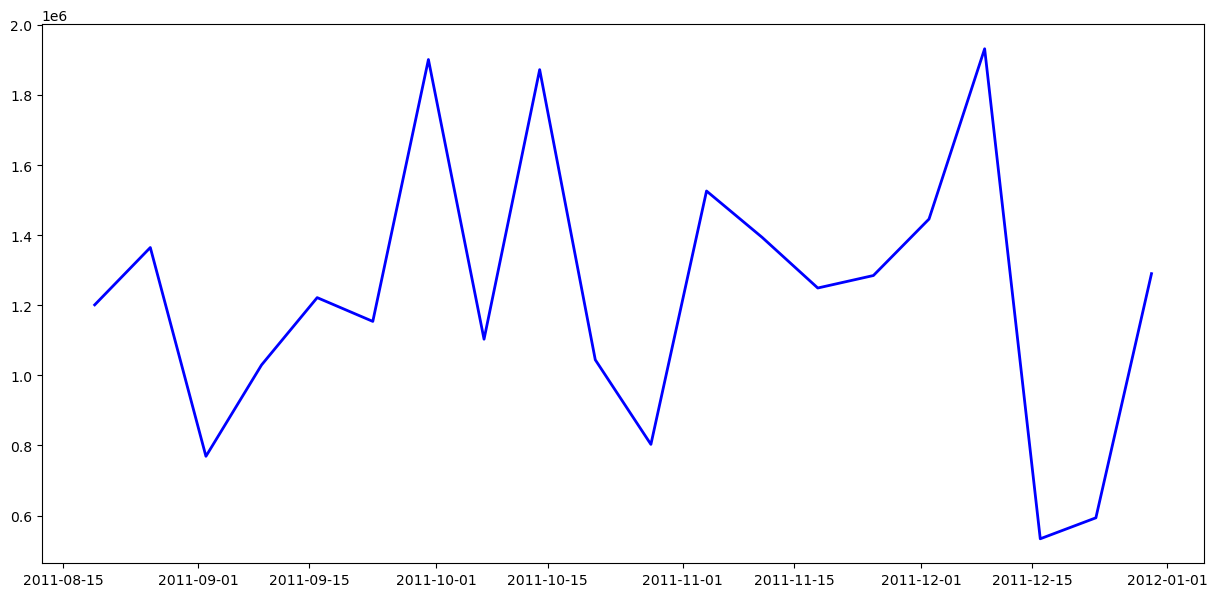

In [15]:
plt.figure(figsize=(15, 7))

# Actual Sales (Haqeeqi Sales - Test set)
plt.plot(dates_test, y_test.values, 
         label='Actual Sales (Haqeeqi Sales)', 
         color='blue', 
         linewidth=2)


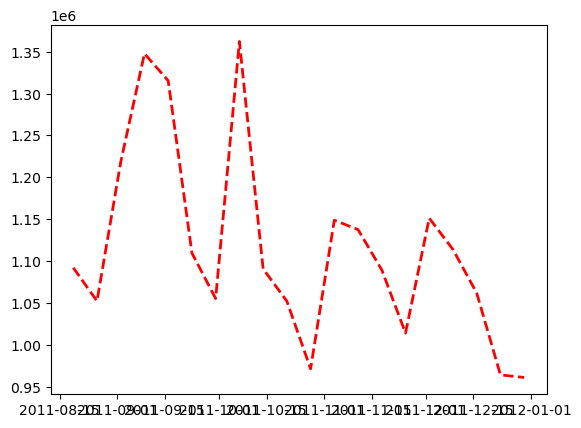

In [16]:
plt.plot(dates_test, y_pred, 
         label='Predicted Sales (Forecast)', 
         color='red', 
         linestyle='--', 
         linewidth=2)

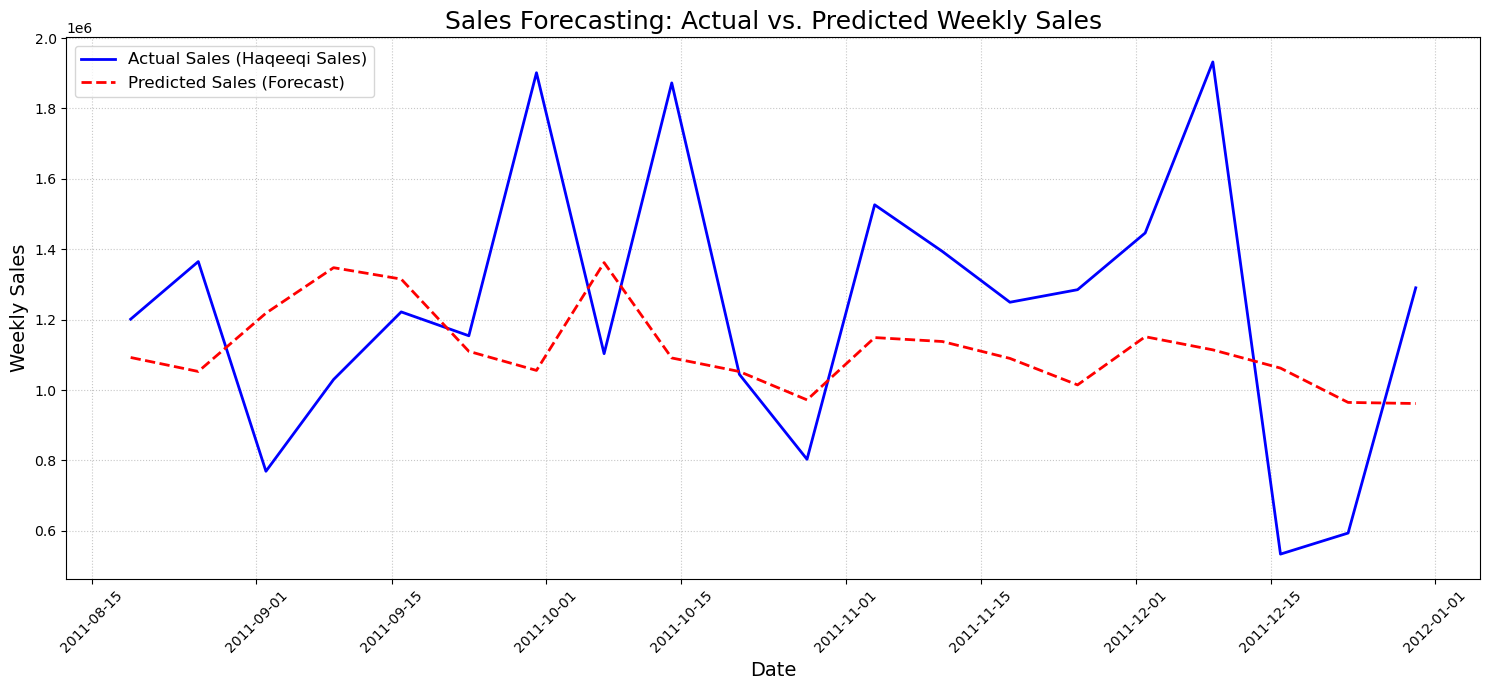

In [18]:
plt.figure(figsize=(15, 7))

# Actual Sales (Haqeeqi Sales - Test set)
plt.plot(dates_test, y_test.values, 
         label='Actual Sales (Haqeeqi Sales)', 
         color='blue', 
         linewidth=2)

# Predicted Sales (Forecast)
plt.plot(dates_test, y_pred, 
         label='Predicted Sales (Forecast)', 
         color='red', 
         linestyle='--', 
         linewidth=2)

# Graph ka Title aur Labels
plt.title('Sales Forecasting: Actual vs. Predicted Weekly Sales', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Weekly Sales', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout() # Plot ko achhe se adjust karta hai
plt.show()